# 1. Importación de librerías

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, explained_variance_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import ListedColormap
import seaborn as sns

# 2. Generación del dataset sintético

In [ ]:
# lectura de los datos
proyecto_df = pd.read_excel('/content/data set Proyecto Final.xlsx')
proyecto_df.head()

,desaño,desmes,H_Construccion_$,H_Refaccion_$,H_Adquisición_Nueva_$,H_Adquisición_Resto_$,H_Otros_$,P_automotores_$,P_maquinarias_$,P-otros$,Tipo de cambio,Tasa de Interes
0,2010.07,Jul.,4282081,152699,1544051,5660828,2220797,3837388,259273,1249680,3.934824,29.605238
1,2010.08,Ago.,4359798,153111,1550875,5703148,2259947,4014747,260441,1259990,3.937610,28.910476
2,2010.09,Set.,4005438,167185,886653,7049683,2247213,4597633,239637,1164202,3.951891,29.332273
3,2010.10,Oct.,4062383,168583,897503,7140713,2315940,4832333,250494,1193453,3.956984,29.608421
4,2010.11,Nov.,4127584,172567,906275,7226265,2411831,5125575,268533,1241870,3.967600,30.543810


In [ ]:
proyecto_df.describe()

,desaño,H_Construccion_$,H_Refaccion_$,H_Adquisición_Nueva_$,H_Adquisición_Resto_$,H_Otros_$,P_automotores_$,P_maquinarias_$,P-otros$,Tipo de cambio,Tasa de Interes
count,189.000000,1.890000e+02,1.890000e+02,1.890000e+02,1.890000e+02,1.890000e+02,1.890000e+02,1.890000e+02,1.890000e+02,189.000000,189.000000
mean,2017.938254,2.621550e+07,3.771733e+06,2.095437e+08,1.195724e+08,8.430568e+07,2.695213e+08,3.864622e+07,1.174013e+08,206.279592,53.790515
std,4.571042,5.475953e+07,7.470863e+06,5.686017e+08,3.243851e+08,2.378353e+08,6.325560e+08,8.426171e+07,2.790139e+08,390.162329,22.553534
min,2010.070000,2.207474e+06,1.526990e+05,8.866530e+05,5.660828e+06,2.220797e+06,3.837388e+06,2.396370e+05,1.164202e+06,3.934824,28.910476
25%,2014.060000,3.412578e+06,1.044559e+06,9.047150e+06,9.373211e+06,5.202887e+06,1.706154e+07,1.137943e+06,4.165550e+06,8.125515,37.498182
50%,2018.050000,9.000642e+06,2.045756e+06,9.263400e+07,2.957281e+07,1.550378e+07,4.445133e+07,6.112407e+06,8.479135e+06,23.668748,46.034737
75%,2022.040000,2.753194e+07,2.787504e+06,1.178265e+08,3.889502e+07,2.740872e+07,9.191814e+07,2.277430e+07,5.562232e+07,113.334474,67.652273
max,2026.030000,3.258690e+08,4.039955e+07,3.461931e+09,1.465120e+09,1.232587e+09,2.791996e+09,3.859431e+08,1.168717e+09,1449.334662,138.748947


In [ ]:
# Ver datos nulos
proyecto_df.isnull().sum()

,0
desaño,0
desmes,0
H_Construccion_$,0
H_Refaccion_$,0
H_Adquisición_Nueva_$,0
H_Adquisición_Resto_$,0
H_Otros_$,0
P_automotores_$,0
P_maquinarias_$,0
P-otros$,0


In [ ]:
#crear una nueva base de datos con columnas de clientes_df

proyecto_tc = proyecto_df[['H_Construccion_$', 'H_Refaccion_$', 'H_Adquisición_Nueva_$', 'H_Adquisición_Resto_$', "H_Otros_$","P_automotores_$","P_maquinarias_$","P-otros$","Tipo de cambio", "Tasa de Interes"]]
#clientes = clientes_df(columns=['purchase_freq_month', 'avg_basket_usd', 'time_on_site_min', 'discount_sensitivity' ])
proyecto_tc

,H_Construccion_$,H_Refaccion_$,H_Adquisición_Nueva_$,H_Adquisición_Resto_$,H_Otros_$,P_automotores_$,P_maquinarias_$,P-otros$,Tipo de cambio,Tasa de Interes
0,4282081,152699,1544051,5660828,2220797,3837388,259273,1249680,3.934824,29.605238
1,4359798,153111,1550875,5703148,2259947,4014747,260441,1259990,3.937610,28.910476
2,4005438,167185,886653,7049683,2247213,4597633,239637,1164202,3.951891,29.332273
3,4062383,168583,897503,7140713,2315940,4832333,250494,1193453,3.956984,29.608421
4,4127584,172567,906275,7226265,2411831,5125575,268533,1241870,3.967600,30.543810
...,...,...,...,...,...,...,...,...,...,...
184,245841780,36416480,2627351617,1448270759,1077965854,2649708173,371473569,1168576186,1427.617647,77.415294
185,267245331,37476893,2885100699,1459129261,1125179763,2650055482,375273934,1021428635,1447.837721,70.501053
186,287985700,38079771,3108850999,1459405911,1155672582,2693790016,385943093,1020452144,1449.334662,68.353333
187,305523547,38908207,3271729446,1461306787,1182184506,2739547068,375877862,1009885315,1409.657100,69.211667


In [ ]:
proyecto_tc.isnull().sum()

,0
H_Construccion_$,0
H_Refaccion_$,0
H_Adquisición_Nueva_$,0
H_Adquisición_Resto_$,0
H_Otros_$,0
P_automotores_$,0
P_maquinarias_$,0
P-otros$,0
Tipo de cambio,0
Tasa de Interes,0


In [ ]:
proyecto_tc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 189 entries, 0 to 188
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   H_Construccion_$       189 non-null    int64  
 1   H_Refaccion_$          189 non-null    int64  
 2   H_Adquisición_Nueva_$  189 non-null    int64  
 3   H_Adquisición_Resto_$  189 non-null    int64  
 4   H_Otros_$              189 non-null    int64  
 5   P_automotores_$        189 non-null    int64  
 6   P_maquinarias_$        189 non-null    int64  
 7   P-otros$               189 non-null    int64  
 8   Tipo de cambio         189 non-null    float64
 9   Tasa de Interes        189 non-null    float64
dtypes: float64(2), int64(8)
memory usage: 14.9 KB


In [ ]:
proyecto_tc.describe()

,H_Construccion_$,H_Refaccion_$,H_Adquisición_Nueva_$,H_Adquisición_Resto_$,H_Otros_$,P_automotores_$,P_maquinarias_$,P-otros$,Tipo de cambio,Tasa de Interes
count,1.890000e+02,1.890000e+02,1.890000e+02,1.890000e+02,1.890000e+02,1.890000e+02,1.890000e+02,1.890000e+02,189.000000,189.000000
mean,2.621550e+07,3.771733e+06,2.095437e+08,1.195724e+08,8.430568e+07,2.695213e+08,3.864622e+07,1.174013e+08,206.279592,53.790515
std,5.475953e+07,7.470863e+06,5.686017e+08,3.243851e+08,2.378353e+08,6.325560e+08,8.426171e+07,2.790139e+08,390.162329,22.553534
min,2.207474e+06,1.526990e+05,8.866530e+05,5.660828e+06,2.220797e+06,3.837388e+06,2.396370e+05,1.164202e+06,3.934824,28.910476
25%,3.412578e+06,1.044559e+06,9.047150e+06,9.373211e+06,5.202887e+06,1.706154e+07,1.137943e+06,4.165550e+06,8.125515,37.498182
50%,9.000642e+06,2.045756e+06,9.263400e+07,2.957281e+07,1.550378e+07,4.445133e+07,6.112407e+06,8.479135e+06,23.668748,46.034737
75%,2.753194e+07,2.787504e+06,1.178265e+08,3.889502e+07,2.740872e+07,9.191814e+07,2.277430e+07,5.562232e+07,113.334474,67.652273
max,3.258690e+08,4.039955e+07,3.461931e+09,1.465120e+09,1.232587e+09,2.791996e+09,3.859431e+08,1.168717e+09,1449.334662,138.748947


In [ ]:
# Regresion Lineal
X = proyecto_tc[['H_Construccion_$', 'H_Refaccion_$', 'H_Adquisición_Nueva_$', 'H_Adquisición_Resto_$', "H_Otros_$","P_automotores_$","P_maquinarias_$","P-otros$"]]
y = proyecto_tc["Tipo de cambio"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_multiple = LinearRegression()
model_multiple.fit(X_train, y_train)

y_pred_multiple = model_multiple.predict(X_test)


In [ ]:
print("Intercepto:", model_multiple.intercept_)
print("Coeficientes:", model_multiple.coef_)

print("\nEvaluación del modelo (Regresión Múltiple):")
print("MAE:", mean_absolute_error(y_test, y_pred_multiple))
print("MSE:", mean_squared_error(y_test, y_pred_multiple))
print("R²:", r2_score(y_test, y_pred_multiple))
print("Varianza explicada:", explained_variance_score(y_test, y_pred_multiple))

Intercepto: -11.73766945623197
Coeficientes: [-2.67655291e-07  2.55279978e-05 -7.70863586e-07 -2.13751552e-06
  1.73918385e-06  7.33197550e-07  7.41917634e-06 -7.47745307e-07]

Evaluación del modelo (Regresión Múltiple):
MAE: 22.718131692623974
MSE: 2263.5442674959063
R²: 0.9832376004827276
Varianza explicada: 0.9845674310349478


Descripción estadística:
       H_Construccion_$  H_Refaccion_$  H_Adquisición_Nueva_$  \
count      1.890000e+02   1.890000e+02           1.890000e+02   
mean       2.621550e+07   3.771733e+06           2.095437e+08   
std        5.475953e+07   7.470863e+06           5.686017e+08   
min        2.207474e+06   1.526990e+05           8.866530e+05   
25%        3.412578e+06   1.044559e+06           9.047150e+06   
50%        9.000642e+06   2.045756e+06           9.263400e+07   
75%        2.753194e+07   2.787504e+06           1.178265e+08   
max        3.258690e+08   4.039955e+07           3.461931e+09   

       H_Adquisición_Resto_$     H_Otros_$  P_automotores_$  P_maquinarias_$  \
count           1.890000e+02  1.890000e+02     1.890000e+02     1.890000e+02   
mean            1.195724e+08  8.430568e+07     2.695213e+08     3.864622e+07   
std             3.243851e+08  2.378353e+08     6.325560e+08     8.426171e+07   
min             5.660828e+06  2.220797e+06     3.837388e+06     2.396

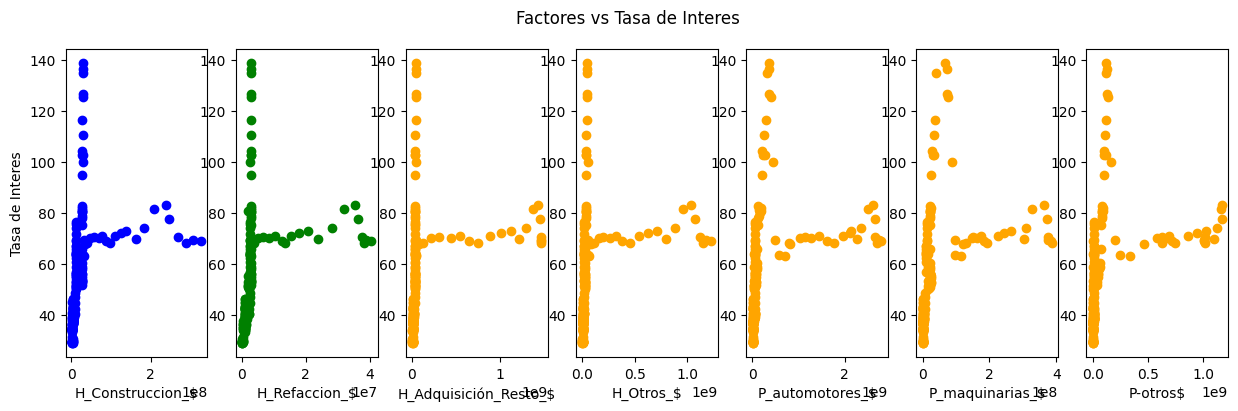

In [ ]:
print("Descripción estadística:")
print(proyecto_tc.describe())

fig, axs = plt.subplots(1, 7, figsize=(15, 4))
axs[0].scatter(proyecto_tc['H_Construccion_$'], proyecto_tc["Tasa de Interes"], color='blue')
axs[0].set_xlabel('H_Construccion_$')
axs[0].set_ylabel("Tasa de Interes")

axs[1].scatter(proyecto_tc['H_Refaccion_$'], proyecto_tc["Tasa de Interes"], color='green')
axs[1].set_xlabel('H_Refaccion_$')

axs[2].scatter(proyecto_tc['H_Adquisición_Resto_$'], proyecto_tc["Tasa de Interes"], color='orange')
axs[2].set_xlabel('H_Adquisición_Resto_$')

axs[3].scatter(proyecto_tc["H_Otros_$"], proyecto_tc["Tasa de Interes"], color='orange')
axs[3].set_xlabel("H_Otros_$")

axs[4].scatter(proyecto_tc["P_automotores_$"], proyecto_tc["Tasa de Interes"], color='orange')
axs[4].set_xlabel("P_automotores_$")

axs[5].scatter(proyecto_tc["P_maquinarias_$"], proyecto_tc["Tasa de Interes"], color='orange')
axs[5].set_xlabel("P_maquinarias_$")

axs[6].scatter(proyecto_tc["P-otros$"], proyecto_tc["Tasa de Interes"], color='orange')
axs[6].set_xlabel("P-otros$")

plt.suptitle("Factores vs Tasa de Interes")
plt.show()

Descripción estadística:
       H_Construccion_$  H_Refaccion_$  H_Adquisición_Nueva_$  \
count      1.890000e+02   1.890000e+02           1.890000e+02   
mean       2.621550e+07   3.771733e+06           2.095437e+08   
std        5.475953e+07   7.470863e+06           5.686017e+08   
min        2.207474e+06   1.526990e+05           8.866530e+05   
25%        3.412578e+06   1.044559e+06           9.047150e+06   
50%        9.000642e+06   2.045756e+06           9.263400e+07   
75%        2.753194e+07   2.787504e+06           1.178265e+08   
max        3.258690e+08   4.039955e+07           3.461931e+09   

       H_Adquisición_Resto_$     H_Otros_$  P_automotores_$  P_maquinarias_$  \
count           1.890000e+02  1.890000e+02     1.890000e+02     1.890000e+02   
mean            1.195724e+08  8.430568e+07     2.695213e+08     3.864622e+07   
std             3.243851e+08  2.378353e+08     6.325560e+08     8.426171e+07   
min             5.660828e+06  2.220797e+06     3.837388e+06     2.396

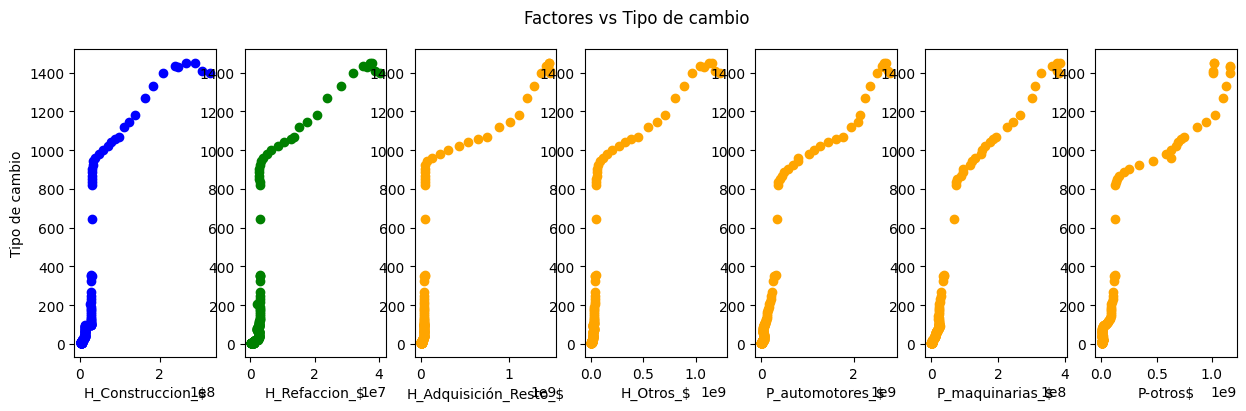

In [ ]:
print("Descripción estadística:")
print(proyecto_tc.describe())

fig, axs = plt.subplots(1, 7, figsize=(15, 4))
axs[0].scatter(proyecto_tc['H_Construccion_$'], proyecto_tc["Tipo de cambio"], color='blue')
axs[0].set_xlabel('H_Construccion_$')
axs[0].set_ylabel("Tipo de cambio")

axs[1].scatter(proyecto_tc['H_Refaccion_$'], proyecto_tc["Tipo de cambio"], color='green')
axs[1].set_xlabel('H_Refaccion_$')

axs[2].scatter(proyecto_tc['H_Adquisición_Resto_$'], proyecto_tc["Tipo de cambio"], color='orange')
axs[2].set_xlabel('H_Adquisición_Resto_$')

axs[3].scatter(proyecto_tc["H_Otros_$"], proyecto_tc["Tipo de cambio"], color='orange')
axs[3].set_xlabel("H_Otros_$")

axs[4].scatter(proyecto_tc["P_automotores_$"], proyecto_tc["Tipo de cambio"], color='orange')
axs[4].set_xlabel("P_automotores_$")

axs[5].scatter(proyecto_tc["P_maquinarias_$"], proyecto_tc["Tipo de cambio"], color='orange')
axs[5].set_xlabel("P_maquinarias_$")

axs[6].scatter(proyecto_tc["P-otros$"], proyecto_tc["Tipo de cambio"], color='orange')
axs[6].set_xlabel("P-otros$")

plt.suptitle("Factores vs Tipo de cambio")
plt.show()